In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

*************************************************************************
*                                                                       *
*                ███████████████████████████████████████                *
*                ▓  ▓▓▓▓  ▓▓  ▓▓▓▓  ▓▓        ▓▓       ▓                *
*                ▓   ▓▓   ▓▓  ▓▓▓▓  ▓▓▓▓▓  ▓▓▓▓▓  ▓▓▓▓▓▓                *
*                ▒        ▒▒  ▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒       ▒                *
*                ▒  ▒  ▒  ▒▒  ▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒  ▒▒▒▒▒▒                *
*                ░  ░░░░  ░░░░    ░░░░░░░  ░░░░░       ░                *
*                ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░                *
*                   https://github.com/wjwoodley/mute                   *
*                                                                       *
* Author:  William Woodley                                              *
* Version: 3.0.0                                                        *
*                                     

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '10' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

## Load Production Rates

In [4]:
Prop = Propagator(logE_mu_max=7.5)

C:\Users\walte\anaconda3\lib\site-packages\crflux\models.py:1068: DeprecationWarning: Please import `InterpolatedUnivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  self.p_frac_spl, self.p_flux_spl, self.n_flux_spl = pickle.load(
C:\Users\walte\anaconda3\lib\site-packages\crflux\models.py:1068: DeprecationWarning: Please import `InterpolatedUnivariateSpline` from the `scipy.interpolate` namespace; the `scipy.interpolate.fitpack2` namespace is deprecated and will be removed in SciPy 2.0.0.
  self.p_frac_spl, self.p_flux_spl, self.n_flux_spl = pickle.load(


In [5]:
df_Pfast = pd.read_csv('Production Rates/P_fast_SouthPole_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_SouthPole_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [40]:
for i,m in enumerate(model_names):
    print(i,m)

0 GlobalSplineFitBeta_SIBYLL23CPP_H-ice
1 HillasGaisser2012 H3a_SIBYLL23CPP_H-ice
2 HillasGaisser2012 H4a_SIBYLL23CPP_H-ice
3 PolyGonato_SIBYLL23CPP_H-ice
4 GaisserStanevTilav 3-gen_SIBYLL23CPP_H-ice
5 GaisserStanevTilav 4-gen_SIBYLL23CPP_H-ice
6 CombinedGHandHG H3a_SIBYLL23CPP_H-ice
7 ZatsepinSokolskaya pamela_SIBYLL23CPP_H-ice
8 ZatsepinSokolskaya default_SIBYLL23CPP_H-ice
9 GaisserHonda_SIBYLL23CPP_H-ice
10 Thunman_SIBYLL23CPP_H-ice
11 SimplePowerlaw27_SIBYLL23CPP_H-ice
12 GlobalSplineFitBeta_SIBYLL23C03_H-ice
13 HillasGaisser2012 H3a_SIBYLL23C03_H-ice
14 HillasGaisser2012 H4a_SIBYLL23C03_H-ice
15 PolyGonato_SIBYLL23C03_H-ice
16 GaisserStanevTilav 3-gen_SIBYLL23C03_H-ice
17 GaisserStanevTilav 4-gen_SIBYLL23C03_H-ice
18 CombinedGHandHG H3a_SIBYLL23C03_H-ice
19 ZatsepinSokolskaya pamela_SIBYLL23C03_H-ice
20 ZatsepinSokolskaya default_SIBYLL23C03_H-ice
21 GaisserHonda_SIBYLL23C03_H-ice
22 Thunman_SIBYLL23C03_H-ice
23 SimplePowerlaw27_SIBYLL23C03_H-ice
24 GlobalSplineFitBeta_SIBYLL-2.3c

## Settings

In [64]:
Heisinger_only = False # Ignore all production models except Heisinger
Pres_conv = True # Variable flux models should converge at the present
f_2sigma = True # Use the 2-sigma hull values of the f-factors (False uses older chi^2 measurement)
Normalize = False # Normalize all production models, and multiply f-factors by Heisinger normalization
Gauss_prod = True # Approximate distribution of production models as gaussian
Gauss_f = True # Approximate distribution of f-factors as gaussian
error = 0.02 # relative systematic error of 14CO samples
Int_f_all = True # Integrate over all f-factors in variable model (False integrates over f-factors only in constant model)
Sample_f = True # Randomize f-factor when sampling 14CO (False assumes average f-factors)

Flux_var = 'linear'

if Heisinger_only and Gauss_prod: # Can't make a gaussian off a single data point
    print("Can't generate a gaussian from only Heisinger production model")
    Gauss_prod = False

if Gauss_prod and len(P_14C)==1:
    print("Can't generate a gaussian from only one production model")
    Gauss_prod = False

## Toy Models

In [82]:
# SET TIME-DEPENDENT FLUX MODEL

t = Prop.t[Prop.i_start:]-Prop.t[-1] # time in years, with 0=present
t_scale = t/(t[-1]-t[0]) # time scaled from -1 to 0, with 0=present

if Flux_var == 'linear':
    if Pres_conv:
        f_var = t_scale # a linear change in flux, converging to 0 at the present
    else:
        f_var = t_scale+1

    da = 0.01
    a_var = np.arange(-0.5,0.5+da, da)
    a_weights = np.ones(len(a_var))
elif Flux_var == 'step':
    if Pres_conv:
        f_var = -1.*(t_scale<-0.5) # a step change in flux halfway through t, converging to 0 at the present
    else:
        f_var = 1.*(t_scale>-0.5)

    da = 0.01
    a_var = np.arange(-0.5,0.5+da, da)
    a_weights = np.ones(len(a_var))

    a_inv = a_var/(a_var-1) #this is the amplitude as defined in previous calculations
elif Flux_var == 'burst':
    f_var = 1.*(t>=(t[0]+3000))*(t<=(t[0]+3100))

    da = 0.1
    a_var = np.arange(da,10.+da, da)
    a_weights = np.ones(len(a_var))

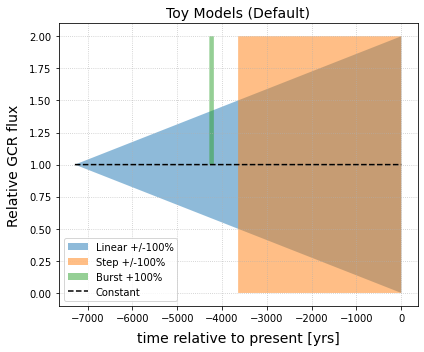

In [83]:
f_const = 1+0*t_scale
f_lin = t_scale+1
f_step = 1.*(t_scale>-0.5)
f_burst = 1.*(t>=(t[0]+3000))*(t<=(t[0]+3100))

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True)
plt.fill_between(t, f_const-f_lin, f_const+f_lin, alpha=0.5, label='Linear +/-100%')
plt.fill_between(t, f_const-f_step, f_const+f_step, alpha=0.5, label='Step +/-100%')
plt.fill_between(t, f_const, f_const+f_burst, alpha=0.5, label='Burst +100%')
plt.plot(t, f_const, ls='--', c='k', label='Constant')
ax.set(xlabel='time relative to present [yrs]',
       ylabel='Relative GCR flux'
      )
ax.legend(loc='lower left', fontsize=10)
plt.title('Toy Models (Default)', fontsize=14)
plt.show()

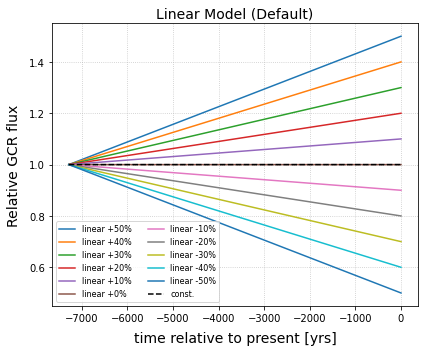

In [84]:
fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True)
for amp in np.arange(0.5,-0.6,-0.1):
    plt.plot(t, f_const+f_lin*amp, label='linear +{:.0f}%'.format(amp*100) if amp>0 else 'linear {:.0f}%'.format(amp*100))
plt.plot(t, f_const, ls='--', c='k', label='const.')
ax.set(xlabel='time relative to present [yrs]',
       ylabel='Relative GCR flux'
      )
ax.legend(loc='lower left', fontsize=8, ncols=2)
plt.title('Linear Model (Default)', fontsize=14)
plt.show()

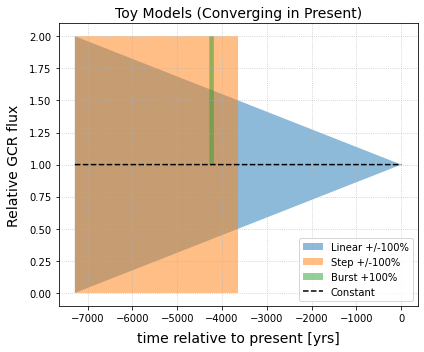

In [85]:
f_lin_pres = t_scale
f_step_pres = -1.*(t_scale<-0.5)

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True)
plt.fill_between(t, f_const-f_lin_pres, f_const+f_lin_pres, alpha=0.5, label='Linear +/-100%')
plt.fill_between(t, f_const-f_step_pres, f_const+f_step_pres, alpha=0.5, label='Step +/-100%')
plt.fill_between(t, f_const, f_const+f_burst, alpha=0.5, label='Burst +100%')
plt.plot(t, f_const, ls='--', c='k', label='Constant')
ax.set(xlabel='time relative to present [yrs]',
       ylabel='Relative GCR flux'
      )
ax.legend(loc='lower right', fontsize=10)
plt.title('Toy Models (Converging in Present)', fontsize=14)
plt.show()

## Integration

In [81]:
if Heisinger_only:
    # The only production model being used is Heisinger
    i = model_names.index('Heisinger')
    prod_cut = np.arange(len(P_14C))[i:i+1]
else:
    # Use all production models
    prod_cut = np.arange(len(P_14C))[132:-1]

In [86]:
Prop.Phi['prod']=P_14C[prod_cut]
C_flow = F.flow_14C(Prop)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [00:37<00:00, 195.65it/s]


In [87]:
C_flow_var = F.flow_14C(Prop, f_var)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [00:36<00:00, 200.82it/s]


## Statistics

In [88]:
if f_2sigma:
    df = pd.read_csv('factors_2sigma_hull.csv', header=None)
    f_factors = np.array([df[1],df[0]]).T
    f_weights = np.ones(len(f_factors))
else:
    df = pd.read_csv('14CO_f_all_ChiSq.csv')
    f_factors = np.array([df['fast'],df['f_neg']]).T[1:]
    f_weights = np.array(np.exp(-df['Chi_sq']/2))[1:] # convert chi^2 to prior weight

C_pred_0 = C_flow @ Prop.S_mat[Prop.i_start:]
# axis0 - Production Model
# axis1 - Production Mode (fast, neg)
# axis2 - Sample Depth

C_pred_var = np.reshape(C_pred_0, (len(C_pred_0),1,2,-1)) + np.reshape(a_var, (1,-1,1,1)) * np.reshape(C_flow_var @ Prop.S_mat[Prop.i_start:], (len(C_flow_var),1,2,-1))
# axis0 - Production Model
# axis1 - Amplitude
# axis2 - Production Mode (fast, neg)
# axis3 - Sample Depth

C_weights = np.ones(len(C_pred_0))
    
if Normalize:
    f_pure_avg = np.average(f_factors, weights=f_weights, axis=0)
    C_norm = np.sum(f_pure_avg @ C_flow * Prop.dh[Prop.i_start:], axis=-1)
    
    C_pred_0 = C_pred_0 / np.reshape(C_norm, (-1,1,1))
    C_pred_var = C_pred_var / (np.reshape(C_norm, (-1,1,1,1)) + np.reshape(a_var,(1,-1,1,1))*np.reshape(np.sum(f_pure_avg @ C_flow_var * Prop.dh[Prop.i_start:],axis=-1),(-1,1,1,1)))
    
    f_factors = f_factors * C_norm[-1]

In [89]:
if Gauss_prod:
    C_0 = np.average(C_pred_0, weights=C_weights, axis=0, keepdims=True)
    # axis0 - Production Model
    # axis1 - Production Mode (fast, neg)
    # axis2 - Sample Depth
    
    C_0_cov = np.moveaxis(np.reshape(
        np.cov(np.reshape(C_pred_0, (len(C_pred_0), -1)), rowvar=False, aweights=C_weights),
        (*np.shape(C_0), *np.shape(C_0)[1:])), (1,3), (-2,-1))
    # axis0 - Production Model
    # axis1 - Sample Depth A
    # axis2 - Sample Depth B
    # axis3 - Production Mode A
    # axis4 - Production Mode B
    
    C_var = np.average(C_pred_var, weights=C_weights, axis=0, keepdims=True)
    # axis0 - Production Model
    # axis1 - Amplitude
    # axis2 - Production Mode (fast, neg)
    # axis3 - Sample Depth
    
    C_var_cov = np.moveaxis(
                    np.reshape(
                        [np.cov(
                            np.reshape(
                                C_pred_var[:,i],
                            (len(C_pred_var), -1)),
                        rowvar=False, aweights=C_weights) for i in range(len(a_var))],
                    (*np.shape(C_var), *np.shape(C_var)[2:])),
                (2,4), (-2,-1)) # move the production mode axes to the bottom
    # axis0 - Production Model
    # axis1 - Amplitude
    # axis2 - Sample Depth A
    # axis3 - Sample Depth B
    # axis4 - Production Mode A
    # axis5 - Production Mode B
    
    C_w = np.ones(1)
    
else:
    C_0 = C_pred_0
    
    C_0_cov = np.zeros((len(C_0), np.shape(C_0)[-1], np.shape(C_0)[-1], 2, 2))
    
    C_var = C_pred_var
    
    C_var_cov = np.zeros((len(C_var), len(a_var), np.shape(C_var)[-1], np.shape(C_var)[-1], 2, 2))
    
    C_w = C_weights/np.sum(C_weights)

f_avg = np.average(f_factors, weights=f_weights, axis=0)
# axis0 - Production Mode

if Gauss_f:
    f = np.average(f_factors, weights=f_weights, axis=0, keepdims=True)
    # axis0 - f-factors
    # axis1 - Production Mode
    
    f_cov = np.reshape(np.cov(f_factors, rowvar=False, aweights=f_weights), (1,2,2))
    # axis0 - f-factors
    # axis1 - Production Mode A
    # axis2 - Production Mode B
    
    f_w = np.ones(1)
    
else:
    f = f_factors
    
    f_cov = np.zeros((len(f),2,2))
    
    f_w = f_weights/np.sum(f_weights)

CO_0 = f @ C_0
# axis0 - Production Model
# axis1 - f-factors
# axis2 - Sample Depth

CO_0_cov = (np.reshape(f,(1,len(f),1,1,1,-1)) @ np.reshape(C_0_cov, (len(C_0),1,*np.shape(C_0_cov)[1:])) @ np.reshape(f,(1,len(f),1,1,-1,1)))[:,:,:,:,0,0] + T(np.reshape(C_0, (len(C_0),1,2,-1))) @ np.reshape(f_cov, (1,len(f),2,2)) @ np.reshape(C_0, (len(C_0),1,2,-1)) + np.sum(np.reshape(C_0_cov, (len(C_0),1,*np.shape(C_0_cov)[1:])) * np.reshape(f_cov, (1,len(f),1,1,2,2)), axis=(-2,-1))
# axis0 - Production Model
# axis1 - f-factors
# axis2 - Sample Depth A
# axis3 - Sample Depth B

CO_var = f @ C_var
# axis0 - Production Model
# axis1 - Amplitude
# axis2 - f-factors
# axis3 - Sample Depth

CO_var_cov = (np.reshape(f,(1,1,len(f),1,1,1,-1)) @ np.reshape(C_var_cov, (len(C_var),len(a_var),1,*np.shape(C_var_cov)[2:])) @ np.reshape(f,(1,1,len(f),1,1,-1,1)))[:,:,:,:,:,0,0] + T(np.reshape(C_var, (len(C_var),len(a_var),1,2,-1))) @ np.reshape(f_cov, (1,1,len(f),2,2)) @ np.reshape(C_var, (len(C_var),len(a_var),1,2,-1)) + np.sum(np.reshape(C_var_cov, (len(C_var),len(a_var),1,*np.shape(C_var_cov)[2:])) * np.reshape(f_cov, (1,1,len(f),1,1,2,2)), axis=(-2,-1))
# axis0 - Production Model
# axis1 - Amplitude
# axis2 - f-factors
# axis3 - Sample Depth A
# axis4 - Sample Depth B

rel_err = error * np.ones(np.shape(CO_0)[-1])
# axis0 - Sample Depth

s_cov = np.diag(rel_err**2)
# axis0 - Sample Depth A
# axis1 - Sample Depth B

Sigma_0 = CO_0_cov * np.reshape(1+s_cov, (1,1,*np.shape(s_cov))) + np.reshape(CO_0, (*np.shape(CO_0),1)) * np.reshape(CO_0, (*np.shape(CO_0)[:-1],1,-1)) * np.reshape(s_cov, (1,1,*np.shape(s_cov)))
Sigma_0 = np.expand_dims(Sigma_0, axis=0)
# axis0 - NONE
# axis1 - Production Model
# axis2 - f-factors
# axis3 - Sample Depth A
# axis4 - Sample Depth B

Sigma_0_inv = np.linalg.inv(Sigma_0)

Sigma_var = CO_var_cov * np.reshape(1+s_cov, (1,1,1,*np.shape(s_cov))) + np.reshape(CO_var, (*np.shape(CO_var),1)) * np.reshape(CO_var, (*np.shape(CO_var)[:-1],1,-1)) * np.reshape(s_cov, (1,1,1,*np.shape(s_cov)))
Sigma_var = np.expand_dims(Sigma_var, axis=0)
# axis0 - NONE
# axis1 - Production Model
# axis2 - Amplitude
# axis3 - f-factors
# axis4 - Sample Depth A
# axis5 - Sample Depth B

Sigma_var_inv = np.linalg.inv(Sigma_var)

CO_var_nof = f_avg @ C_var
# axis0 - Production Model
# axis1 - Amplitude
# axis2 - Sample Depth

CO_var_nof_cov = f_avg @ C_var_cov @ f_avg
# axis0 - Production Model
# axis1 - Amplitude
# axis2 - f-factors
# axis3 - Sample Depth A
# axis4 - Sample Depth B

Sigma_var_nof = CO_var_nof_cov * np.reshape(1+s_cov, (1,1,*np.shape(s_cov))) + np.reshape(CO_var_nof, (*np.shape(CO_var_nof),1)) * np.reshape(CO_var_nof, (*np.shape(CO_var_nof)[:-1],1,-1)) * np.reshape(s_cov, (1,1,*np.shape(s_cov)))
Sigma_var_nof = np.expand_dims(Sigma_var_nof, axis=0)

Sigma_var_nof_inv = np.linalg.inv(Sigma_var_nof)

## Sensitivity Calculation

In [17]:
def get_probs(N=1000, C=C_pred_0, samp_f=Sample_f, int_f=Int_f_all):
    i = np.random.choice(np.arange(len(C)), N, p=C_weights/np.sum(C_weights))
    s = np.random.normal(0,rel_err,(N,np.shape(C)[-1]))
    if samp_f:
        j = np.random.choice(np.arange(len(f_factors)), N, p=f_weights/np.sum(f_weights))
        x = (np.reshape(f_factors[j], (-1,1,2))@C[i])[:,0]*(1+s)
    else:
        x = (np.reshape(f_avg, (1,1,2))@C[i])[:,0]*(1+s)
        
    dCO_0 = np.reshape(x, (len(x),1,1,-1,1))-np.reshape(CO_0, (1,len(CO_0),len(f),-1,1))
    # axis0 - Sample #
    # axis1 - Production Model
    # axis2 - f-factors
    # axis3 - Sample Depth
    # axis4 - NONE
    P_0 = np.sum(np.exp(-T(dCO_0)@Sigma_0_inv@dCO_0/2)[:,:,:,0,0]/np.sqrt(np.linalg.det(2*np.pi*Sigma_0))*np.reshape(C_w, (1,-1,1))*np.reshape(f_w, (1,1,-1)), axis=(-2,-1))
    
    if int_f:
        dCO_var = np.reshape(x, (len(x),1,1,1,-1,1))-np.reshape(CO_var, (1,len(CO_var),len(a_var),len(f),-1,1))
        # axis0 - Sample #
        # axis1 - Production Model
        # axis2 - Amplitude
        # axis3 - f-factors
        # axis4 - Sample Depth
        # axis5 - NONE
        P_var = np.sum(np.exp(-T(dCO_var)@Sigma_var_inv@dCO_var/2)[:,:,:,:,0,0]/np.sqrt(np.linalg.det(2*np.pi*Sigma_var))*np.reshape(a_weights, (1,1,-1,1))*np.reshape(C_w, (1,-1,1,1))*np.reshape(f_w, (1,1,1,-1)), axis=(-3,-2,-1))/np.sum(a_weights)
        
    else:
        dCO_var = np.reshape(x, (len(x),1,1,-1,1))-np.reshape(CO_var_nof, (1,len(CO_var_nof),len(a_var),-1,1))
        P_var = np.sum(np.exp(-T(dCO_var)@Sigma_var_nof_inv@dCO_var/2)[:,:,:,0,0]/np.sqrt(np.linalg.det(2*np.pi*Sigma_var_nof))*np.reshape(a_weights, (1,1,-1))*np.reshape(C_w, (1,-1,1)), axis=(-2,-1))/np.sum(a_weights)
    
    return P_0, P_var

100%|█████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 730.99it/s]


[0.002699796063260186, 6.334248366623973e-05, 5.733031437583867e-07]
[0.08488922795754422, 0.006068995047350404, 0.00022209649014318515]


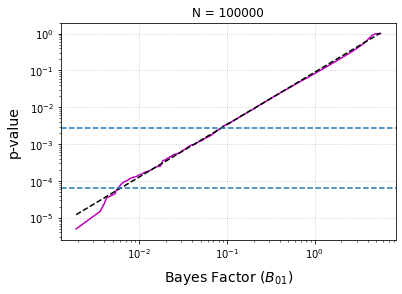

[ 1.42234874 -2.40648663]


100%|████████████████████████████████████████████████████████████████████████████████| 101/101 [00:01<00:00, 58.92it/s]


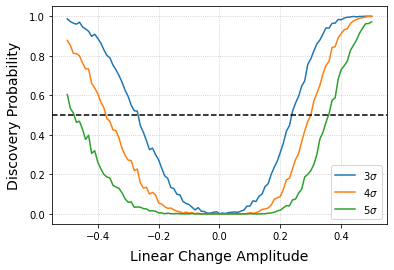

[-0.27 -0.38 -0.48]
[0.24 0.31 0.36]


In [18]:
M = 100
N = 1000
P = np.reshape(np.swapaxes([get_probs(M) for i in tqdm(range(N))], 0,1), (2,-1))

B_01 = P[0]/P[1]

B = np.sort(B_01)
p = (np.arange(len(B_01))+0.5)/len(B_01)

coef = np.polyfit(np.log(B[:1000]),np.log(p[:1000]),1)
poly1d_fn = np.poly1d(coef) 
#poly1d_fn is now a function which takes in x and returns an estimate for y

# ln(p) = coef[0]*ln(B) + coef[1]
# ln(B) = (ln(p)-coef[1])/coef[0]
sigs = [3,4,5]
B_thr = [np.exp((np.log(stats.norm.sf(s)*2)-coef[1])/coef[0]) for s in sigs]
print([stats.norm.sf(s)*2 for s in sigs])
print(B_thr)

plt.plot(B,p, '-m')
plt.plot(B, np.exp(poly1d_fn(np.log(B))), '--k')
for s in sigs:
    plt.axhline(stats.norm.sf(s)*2, ls='--')
plt.xscale('log')
plt.xlabel(r'Bayes Factor ($B_{01}$)')
plt.yscale('log')
plt.ylim(p[0]/2.,2.)
plt.ylabel('p-value')
plt.title('N = {}'.format(N*M))
plt.show()

print(coef)

P_var = np.swapaxes([get_probs(1000, C_pred_var[:,i]) for i in tqdm(range(len(a_var)))], 0,1)

B_var = P_var[0]/P_var[1]

discovery = np.array([np.sum(B_var<=b, axis=-1)/np.shape(B_var)[-1] for b in B_thr])

sensitivity_low = a_var[np.array([np.arange(len(discovery[i]))[discovery[i]<0.5][0]-1 for i in range(len(discovery))])]
sensitivity_high = a_var[np.array([np.arange(len(discovery[i]))[discovery[i]<0.5][-1]+1 for i in range(len(discovery))])]

for i,d in enumerate(discovery):
    plt.plot(a_var, d, label=r'{}$\sigma$'.format(sigs[i]))
plt.axhline(0.5, c='k', ls='--')
plt.xlabel('{} Change Amplitude'.format(Flux_var.capitalize()))
plt.ylabel('Discovery Probability')
plt.legend()
plt.show()

print(sensitivity_low)
print(sensitivity_high)